In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set_theme()


In [ ]:
character_df = pd.read_parquet("../data/pipeline/hathi_all/final/characters.parquet")

In [105]:
fashion_df = pd.read_parquet(
    "../data/pipeline/hathi_all/final/fashion_mentions.parquet"
)

In [106]:
hathi_metadata = pd.read_csv("../data/hathimeta/titlemeta.tsv", sep="\t")
hathi_metadata.loc[:, "book_id"] = hathi_metadata.docid.apply(lambda x: x + ".clean")
hathi_metadata = hathi_metadata.set_index("book_id")

/tmp/ipykernel_3215603/3717131593.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  hathi_metadata = pd.read_csv("../data/hathimeta/titlemeta.tsv", sep="\t")


In [95]:
# read in pronoun data
from pathlib import Path
import json
from fashion.pipeline.steps.extract_pronouns import gender_pronouns


def read_dep_pronoun_data(pron_dir: Path):
    for file in tqdm(pron_dir.glob("*.jsonl")):
        with open(file, "r") as f:
            for line in f:
                obj = json.loads(line)
                if obj["possessive_pronoun"] is None:
                    continue
                for gender, pronouns in gender_pronouns.items():
                    if obj["possessive_pronoun"] in pronouns:
                        yield {
                            "mention_id": obj["mention_id"],
                            "gender": gender,
                        }


def read_pronoun_data(pron_dir: Path):
    for file in tqdm(pron_dir.glob("*.jsonl")):
        with open(file, "r") as f:
            for line in f:
                obj = json.loads(line)
                if len(obj["gender"]) == 0:
                    continue
                agg_gender = max(
                    obj["gender"].keys(), key=lambda x: len(obj["gender"][x])
                )
                yield {"mention_id": obj["mention_id"], "gender": agg_gender, "all_genders": obj["gender"]}


loc_pronouns = pd.DataFrame(
    list(read_pronoun_data(Path("../data/pipeline/hathi_all/local_pronouns/")))
)
dep_pronouns = pd.DataFrame(
    list(read_dep_pronoun_data(Path("../data/pipeline/hathi_all/pronouns/")))
)


16it [00:24,  1.53s/it]
16it [00:08,  1.88it/s]


In [96]:
loc_pronouns.gender.value_counts(), dep_pronouns.gender.value_counts()

(gender
 male         2541538
 female       1531799
 nonbinary     633005
 other            206
 Name: count, dtype: int64,
 gender
 male         1028071
 female        546880
 nonbinary     171637
 other             26
 Name: count, dtype: int64)

In [107]:
merged_fashion_df = fashion_df.merge(
    loc_pronouns.rename({"gender": "gender_local_pron"}, axis=1),
    left_on="mention_id",
    right_on="mention_id",
    how="left",
)
merged_fashion_df = merged_fashion_df.merge(
    dep_pronouns.rename({"gender": "gender_dep_pron"}, axis=1),
    left_on="mention_id",
    right_on="mention_id",
    how="left",
)



In [108]:
# merge fashion and character data

char_fashion = merged_fashion_df.dropna(subset=["character_id"])
char_fashion.character_id = pd.to_numeric(char_fashion.character_id)
char_fashion = char_fashion.set_index(["book_id", "character_id"])


/tmp/ipykernel_3215603/1583668402.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  char_fashion.character_id = pd.to_numeric(char_fashion.character_id)


In [109]:
merged = char_fashion.merge(
    character_df.dropna(subset=["gender"])
    .drop(["character_start_idx", "character_end_idx"], axis=1)
    .rename({"gender": "gender_booknlp"}, axis=1)
    .set_index(["book_id", "character_id"]),
    how="inner",
    left_index=True,
    right_index=True,
    suffixes=("_fashion", "_char"),
)

In [110]:
merged = merged.merge(
    hathi_metadata.inferreddate.dropna(), left_on="book_id", right_index=True
)

In [111]:
merged.loc[:, "decade"] = merged.inferreddate // 10

In [112]:
merged.groupby("book_id").decade.first().value_counts()

decade
190.0    7670
191.0    6922
189.0    6415
188.0    3261
192.0    2615
187.0    2174
185.0    2075
186.0    1806
183.0    1678
184.0    1614
182.0    1268
181.0     481
180.0     410
198.0       1
Name: count, dtype: int64

In [88]:
merged[
    merged.term.eq("skirt") & merged.decade.eq(181) & merged.gender_local_pron.eq("male")
].iloc[:50]  # ["sentence"]

mention_id   term  \
book_id                  character_id                      
mdp.39015039248037.clean 2397              695521  skirt   
                         2397              695521  skirt   
mdp.39015064002879.clean 203               786456  skirt   
                         203               786456  skirt   
                         203               786456  skirt   
mdp.39015065444997.clean 1261              651772  skirt   
mdp.39015074634638.clean 1158             1291804  skirt   
                         4438             1291804  skirt   
                         1158             1291804  skirt   
njp.32101030854416.clean 42529           15514249  skirt   
njp.32101037977566.clean 117             15539434  skirt   
                         214             15539434  skirt   
                         214             15539434  skirt   
                         214             15539434  skirt   
njp.32101067173060.clean 4081            15972763  skirt   
                         4556            15972763  skirt   
                         4081            15972763  skirt   
                         4081            15972773  skirt   
                         173             15972773  skirt   
njp.32101067628865.clean 1213            16074632  skirt   
                         1213            16074632  skirt   
                         1213            16074632  skirt   
                         1213            16074632  skirt   
                         1213            16074632  skirt   
njp.32101077790861.clean 22214           16831983  skirt   
                         22214           16831983  skirt   
                         22214           16831983  skirt   
                         0               16831983  skirt   
                         0               16831983  skirt   
                         22214           16831983  skirt   
nyp.33433074952239.clean 0               12622276  skirt   
                         0               12622276  skirt   
                         2176            12622276  skirt   
nyp.33433075729909.clean 0               12527249  skirt   
                         974             12527249  skirt   
                         0               12527249  skirt   
                         0               12527249  skirt   
nyp.33433075769756.clean 141             13286398  skirt   
                         130             13286398  skirt   
nyp.33433075772552.clean 136             13608190  skirt   
                         97              13608190  skirt   
nyp.33433075840219.clean 431             14133784  skirt   
                         855             14133784  skirt   
                         431             14133784  skirt   
                         855             14133784  skirt   
                         431             14133784  skirt   
                         431             14133784  skirt   
nyp.33433076095037.clean 297             11596854  skirt   
                         297             11596854  skirt   
nyp.33433076095045.clean 291             12069520  skirt   

                                                                                sentence  \
book_id                  character_id                                                      
mdp.39015039248037.clean 2397          Ask him of the manners of the \npeople, and he...   
                         2397          Ask him of the manners of the \npeople, and he...   
mdp.39015064002879.clean 203           John Fitz was in this state of distraction, hi...   
                         203           John Fitz was in this state of distraction, hi...   
                         203           John Fitz was in this state of distraction, hi...   
mdp.39015065444997.clean 1261          the skirt reaching halfway \nto their knees; w...   
mdp.39015074634638.clean 1158          As he came into the middle \nof the room, he t...   
                         4438          As he came into the middle \nof the room, he t...  

In [76]:
from fashion.sources import HathiAll


def show(row):
    text = HathiAll().load_text(row.book_id).text
    char_start = int(row.character_start_idx)
    char_end = int(row.character_end_idx)
    print(row.mention_id)
    print(char_start, char_end)
    split = [
        text[row.sentence_start_idx - 50 : char_start],
        text[char_start:char_end],
        text[char_end : row.sentence_end_idx + 50],
    ]
    print(f"{split[0]}[[{split[1]}]]{split[2]}")

In [ ]:
merged[
    merged.term.eq("skirt")
    & merged.decade.eq(181)
    & merged.gender_local_pron.eq("male")
].reset_index().iloc[0]

book_id                                         mdp.39015039248037.clean
character_id                                                        2397
mention_id                                                        695521
term                                                               skirt
sentence               Ask him of the manners of the \npeople, and he...
start_idx                                                             70
end_idx                                                               75
sentence_start_idx                                                 66500
sentence_end_idx                                                   66652
adjectives_fashion                                                    []
character_start_idx                                              66543.0
character_end_idx                                                66545.0
gender_local_pron                                                   male
adjectives_char                                    

In [89]:
pronouns[pronouns.mention_id.eq(15539434)]

,mention_id,gender,all_genders
2726953,15539434,male,"{'female': ['her'], 'male': ['he', 'his']}"


In [92]:
merged[merged.mention_id.eq(15539434)]

mention_id   term  \
book_id                  character_id                      
njp.32101037977566.clean 117             15539434  skirt   
                         214             15539434  skirt   
                         214             15539434  skirt   
                         214             15539434  skirt   

                                                                                sentence  \
book_id                  character_id                                                      
njp.32101037977566.clean 117           The former he knew he must be, by \nhis mother...   
                         214           The former he knew he must be, by \nhis mother...   
                         214           The former he knew he must be, by \nhis mother...   
                         214           The former he knew he must be, by \nhis mother...   

                                       start_idx  end_idx  sentence_start_idx  \
book_id                  character_id                                           
njp.32101037977566.clean 117                 484      489              222152   
                         214                 484      489              222152   
                         214                 484      489              222152   
                         214                 484      489              222152   

                                       sentence_end_idx adjectives_fashion  \
book_id                  character_id                                        
njp.32101037977566.clean 117                     222950                 []   
                         214                     222950                 []   
                         214                     222950                 []   
                         214                     222950                 []   

                                       character_start_idx  character_end_idx  \
book_id                  character_id                                           
njp.32101037977566.clean 117                      222645.0           222648.0   
                         214                      222799.0           222804.0   
                         214                      222906.0           222908.0   
                         214                      222224.0           222227.0   

                                      gender_local_pron  \
book_id                  character_id                     
njp.32101037977566.clean 117                       male   
                         214                       male   
                         214                       male   
                         214                       male   

                                                                      all_genders  \
book_id                  character_id                                               
njp.32101037977566.clean 117           {'female': ['her'], 'male': ['he', 'his']}   
                         214           {'female': ['her'], 'male': ['he', 'his']}   
                         214           {'female': ['her'], 'male': ['he', 'his']}   
                         214           {'female': ['her'], 'male': ['he', 'his']}   

                                                                         adjectives_char  \
book_id                  character_id                                                      
njp.32101037977566.clean 117           [little, poor, anxious, poor, rapacious, young...   
                         214                                                      [much]   
                         214                                                      [much]   
                         214                                                      [much]   

                                      gender_booknlp  inferreddate  decade  
book_id                  character_id                                       
njp.32101037977566.clean 117                 she/her        1813.0   181.0  
                         214    

In [91]:
show(
    merged[
        merged.term.eq("skirt")
        & merged.decade.eq(181)
        & merged.gender_local_pron.eq("male")
        & merged.mention_id.eq(15539434)
    ]
    .reset_index()
    .iloc[0]
)


15539434
222645 222648
rus 
to be silent and inactive at the same 
time. The former he knew he must be, by 
his mother's absolute command, while his 
sister practised; therefore, after silently 
seeking about for employment, he beckoned 
Adelaide to approach the fire to behold 
a beautiful appearance in it; when, 
not in the least suspecting he had thrown 
a paper of gunpowder under the grate, she 
unhesitatingly drew near, and almost instantaneously 
the explosion succeeded ; 
when, providentially, the probable mischief 
extended no further than the skirt of [[her]]
frock, where the powder lodged, and burst 
out into innumerable little flames; but, 
fortunately, being bombasine, they did not 
expand, and afforded Cyrus an opportunity 
of promptly extinguishing them, by 
aid of Miss Wattling's new cloth pelisse, 
which he unceremoniously snatched from 
a chair. 
For some moments the greatest consternation 
preva


In [ ]:
merged

In [30]:
sns.set_palette("colorblind")

In [ ]:
def compare_plots(term):
    fig, (local_ax, dep_ax, booknlp_ax, exclude_narrator) = plt.subplots(
        1, 4, figsize=(12, 5), sharey=True
    )
    sns.lineplot(
        data=merged.groupby(["decade", "term"])
        .gender_local_pron.value_counts(normalize=True)[:, term]
        .reset_index(),
        x="decade",
        y="proportion",
        hue="gender_local_pron",
        hue_order=["male", "female", "nonbinary", "None"],
        ax=local_ax,
        # hue_order=["he/him/his", "she/her", "they/them/their", "ze/zem/zir/hir"],
    )
    sns.move_legend(local_ax, "lower right")
    local_ax.set_title("Local Pronoun")

    sns.lineplot(
        data=merged.groupby(["decade", "term"])
        .gender_dep_pron.value_counts(normalize=True)[:, term]
        .reset_index(),
        x="decade",
        y="proportion",
        hue="gender_dep_pron",
        hue_order=["male", "female", "nonbinary", "None"],
        ax=dep_ax,
        # hue_order=["he/him/his", "she/her", "they/them/their", "ze/zem/zir/hir"],
    )
    sns.move_legend(dep_ax, "lower right")
    dep_ax.set_title("Dep Pronoun")

    sns.lineplot(
        data=merged.groupby(["decade", "term"])
        .gender_booknlp.value_counts(normalize=True)[:, term]
        .reset_index(),
        x="decade",
        y="proportion",
        hue="gender_booknlp",
        hue_order=["he/him/his", "she/her", "they/them/their", "ze/zem/zir/hir"],
        ax=booknlp_ax,
    )
    sns.move_legend(booknlp_ax, "lower right")
    booknlp_ax.set_title("BookNLP")

    sns.lineplot(
        data=merged[merged.index.get_level_values("character_id") != 0]
        .groupby(["decade", "term"])
        .gender_booknlp.value_counts(normalize=True)[:, term]
        .reset_index(),
        x="decade",
        y="proportion",
        hue="gender_booknlp",
        hue_order=["he/him/his", "she/her", "they/them/their", "ze/zem/zir/hir"],
        ax=exclude_narrator,
    )
    sns.move_legend(exclude_narrator, "lower right")
    exclude_narrator.set_title("Exclude Narrator")

    plt.tight_layout()
    plt.show()


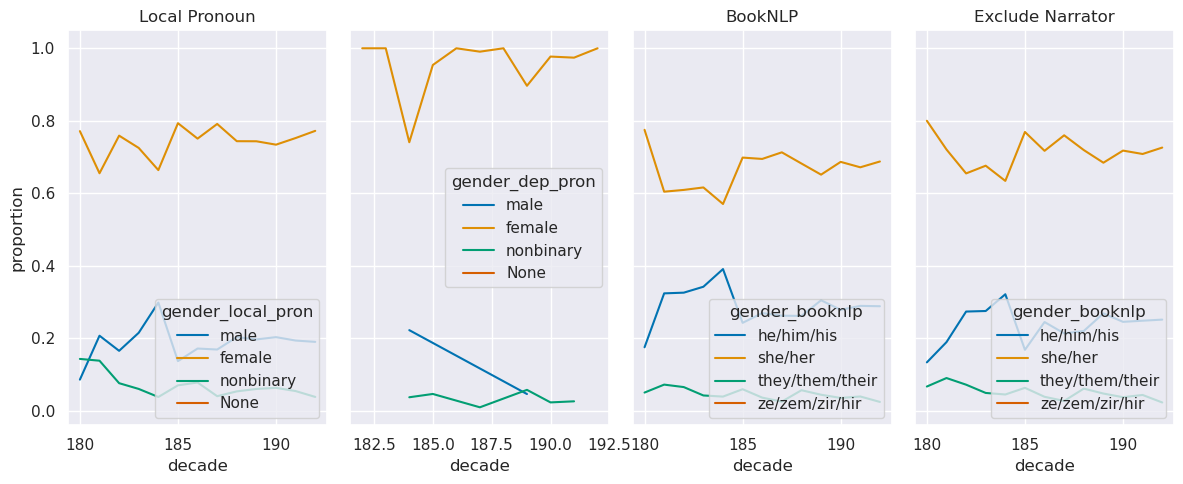

In [113]:
compare_plots("muslin")

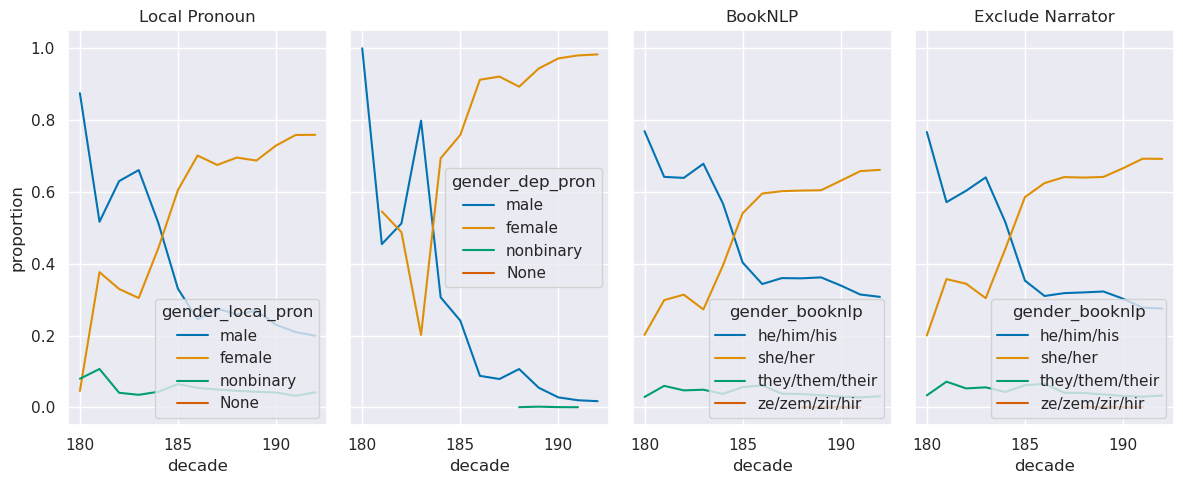

In [114]:
compare_plots("skirt")

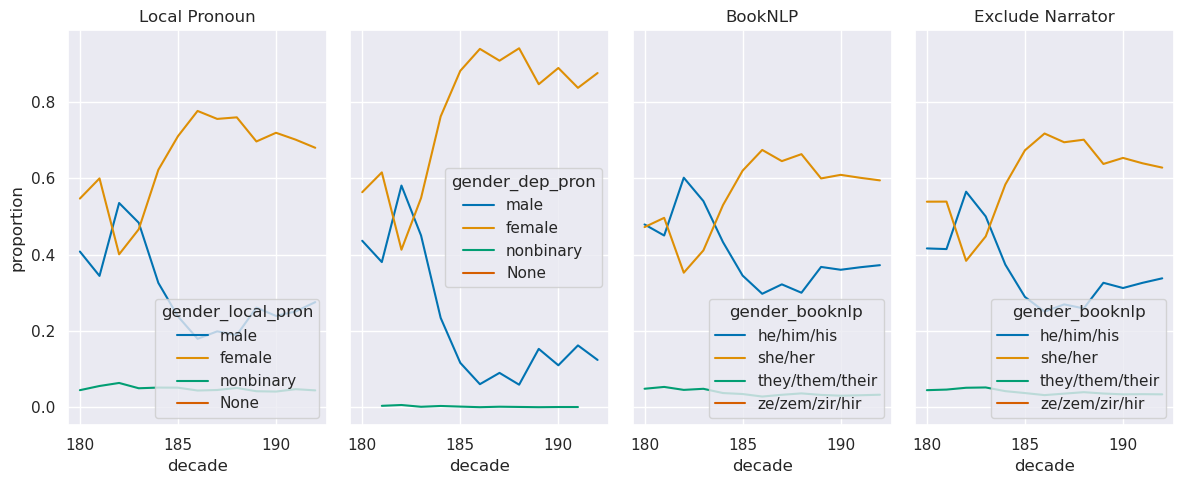

In [115]:
compare_plots("bonnet")

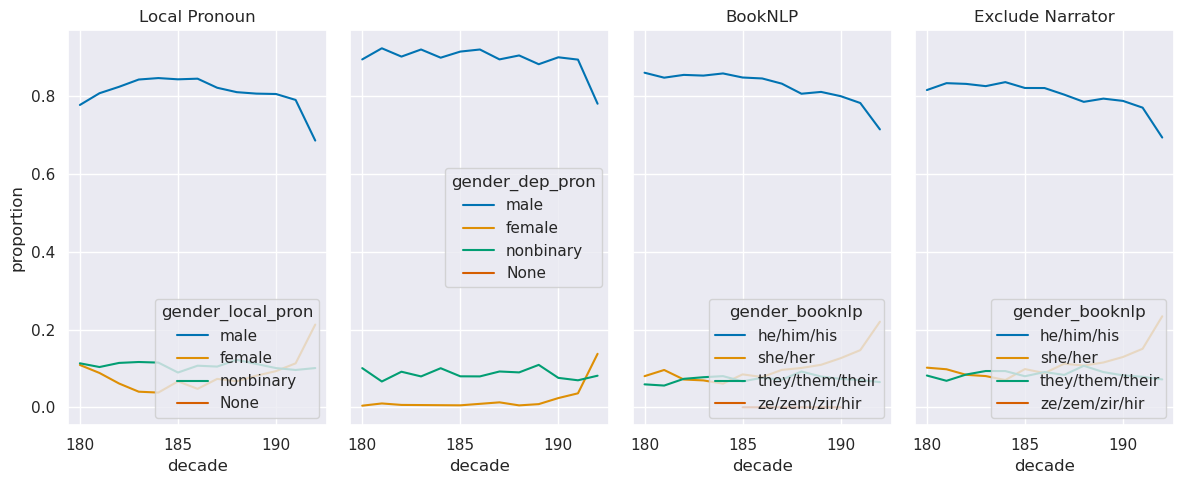

In [116]:
compare_plots("breeches")

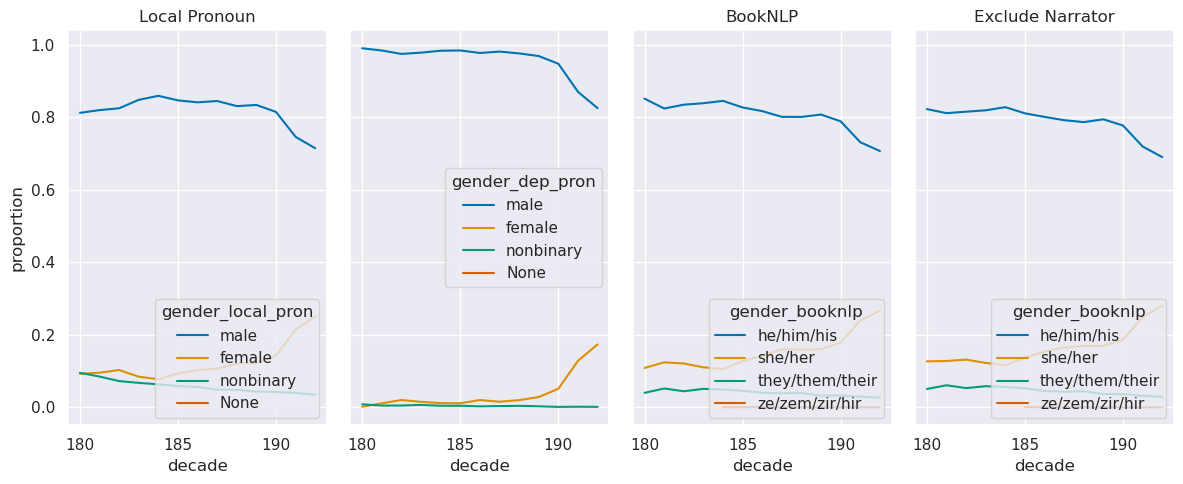

In [117]:
compare_plots("coat")

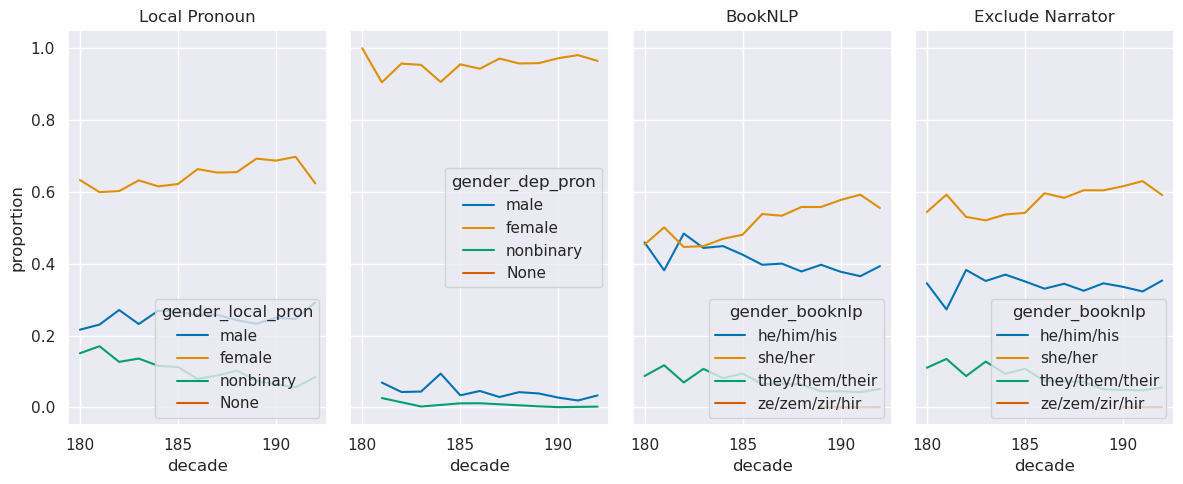

In [118]:
compare_plots("petticoat")

In [122]:
merged.head()

mention_id    term  \
book_id             character_id                       
chi.086202240.clean 0               17370773  shorts   
                    0               17370773  shorts   
                    0               17370773  shorts   
                    0               17370773  shorts   
                    0               17370773  shorts   

                                                                           sentence  \
book_id             character_id                                                      
chi.086202240.clean 0             How long I remained in shorts I cannot novembe...   
                    0             How long I remained in shorts I cannot novembe...   
                    0             How long I remained in shorts I cannot novembe...   
                    0             How long I remained in shorts I cannot novembe...   
                    0             How long I remained in shorts I cannot novembe...   

                                  start_idx  end_idx  sentence_start_idx  \
book_id             character_id                                           
chi.086202240.clean 0                    23       29                4200   
                    0                    23       29                4200   
                    0                    23       29                4200   
                    0                    23       29                4200   
                    0                    23       29                4200   

                                  sentence_end_idx adjectives_fashion  \
book_id             character_id                                        
chi.086202240.clean 0                         4409                 []   
                    0                         4409                 []   
                    0                         4409                 []   
                    0                         4409                 []   
                    0                         4409                 []   

                                  character_start_idx  character_end_idx  \
book_id             character_id                                           
chi.086202240.clean 0                          4230.0             4231.0   
                    0                          4209.0             4210.0   
                    0                          4254.0             4255.0   
                    0                          4154.0             4156.0   
                    0                          4334.0             4336.0   

                                 gender_local_pron all_genders  \
book_id             character_id                                 
chi.086202240.clean 0                          NaN         NaN   
                    0                          NaN         NaN   
                    0                          NaN         NaN   
                    0                          NaN         NaN   
                    0                          NaN         NaN   

                                 gender_dep_pron  \
book_id             character_id                   
chi.086202240.clean 0                        NaN   
                    0                        NaN   
                    0                        NaN   
                    0                        NaN   
                    0                        NaN   

                                                                    adjectives_char  \
book_id             character_id                                                      
chi.086202240.clean 0             [more, content, gay, aged, faithful, astonishe...   
                    0             [more, content, gay, aged, faithful, astonishe...   
                    0             [more, content, gay, aged, faithful, astonishe...   
                    0             [more, content, gay, aged, faithful, astonishe...   
                    0             [more, content, gay, aged, faithful, astonishe...   

               

In [130]:
# construct vocab and indices

genders = []
features = []
decades = []

# keep only he/him and she/her (not they/them, which tends to be noisy in our data)
subset = merged.dropna(subset=["gender_dep_pron"])
for row in tqdm(subset.itertuples(), total=len(subset)):
    if row.gender_dep_pron[0] in ("t", "z", "n", "o"):
        continue
    adjs = [adj for adj in row.adjectives_fashion if adj is not None]
    if len(adjs) == 0:
        continue
    decades.append(row.decade)
    genders.append(row.gender_dep_pron)
    row_feats = [f"term_{row.term.lower()}"]
    # row_feats += [adj.lower() for adj in adjs]
    # row_feats += [f"adj_{adj} {row.term}".lower() for adj in adjs]
    features.append(row_feats)

100%|██████████████████████████████████████████| 5062910/5062910 [00:09<00:00, 549573.65it/s]


In [131]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

encoder = CountVectorizer(
    input="content",
    lowercase=False,
    preprocessor=None,
    tokenizer=lambda x: x,
    min_df=100,
)
encoder.fit(features)

le = LabelEncoder()
le.fit(genders)


def get_features(split):
    split_g = []
    split_f = []
    for i in split:
        split_g.append(genders[i])
        split_f.append(features[i])
    return split_g, split_f


def train_classifier(split):
    genders, features = get_features(split)
    X = encoder.transform(features)
    y = le.transform(genders)
    model = LogisticRegression(penalty="l1", solver="liblinear")
    model.fit(X, y)

    print(f1_score(y[:1000], model.predict(X[:1000])))

    # print(model.score(X[:1000], y[:1000]))
    return model

/data/naitian/fashion/.pixi/envs/default/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [132]:
le.classes_

array(['female', 'male'], dtype='<U6')

In [133]:
len(genders), len(features), len(decades)

(950975, 950975, 950975)

In [134]:
models = []
for decade in range(180, 192):
    print(decade)
    split = np.where(np.array(decades) == decade)[0]
    model = train_classifier(split)
    models.append(model)

180
0.8270348837209303
181
0.8045977011494253
182
0.801423487544484
183
0.8218029350104822
184
0.8373071528751753
185
0.7960363336085879
186
0.7887579329102448
187
0.7608695652173914
188
0.7557117750439367
189
0.6943231441048034
190
0.7614678899082569
191
0.8064257028112449


In [137]:
def _():
    for i, decade in enumerate(range(180, 192)):
        print("======", decade, "=======")
        model = models[i]
        features = encoder.get_feature_names_out()
        k = 10

        print(le.classes_[1])
        for i in model.coef_.argsort()[0, -k:][::-1]:
            print(f"{features[i]}\t{model.coef_[0, i]}")

        print()

        print(le.classes_[0])
        for i in model.coef_.argsort()[0, :k]:
            print(f"{features[i]}\t{model.coef_[0, i]}")


_()

====== 180 =======
male
term_coat	4.1630305072941916
term_uniform	2.9551928922166883
term_cap	2.667536854704425
term_breeches	2.4051465557793663
term_helmet	2.222824998985412
term_shirt	2.139443389587241
term_waistcoat	2.0949916274755265
term_livery	1.999707482128768
term_cover	1.8943469664709385
term_boots	1.8371885526309943

female
term_apron	-3.7686135136649987
term_caps	-3.1932493687614443
term_bonnet	-2.941934940104735
term_bands	-2.78778426065328
term_sleeve	-2.7877842606532792
term_stays	-2.7877842602954455
term_pelisse	-2.787784260295378
term_periwig	-2.605488738316892
term_liveries	-2.6054627038593234
term_coif	-2.382345187002677
====== 181 =======
male
term_coat	3.4864107656344094
term_shirt	3.2779294373476398
term_uniform	3.2588812423769418
term_waistcoat	3.1362789202846106
term_breeches	2.862985585284934
term_bow	2.3033697973063822
term_helmet	2.1980092816916823
term_clothing	2.1408508678517326
term_accoutrements	2.140773111711788
term_pipe	2.0802262460352994

female
term_v